Image Recognition
===

This notebook will create a convolutional neural network to classify images in either the mnist or cifar-10 datasets.

In [1]:
# TODO: Imports
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
# Keras to create the neural network

from tensorflow.keras.datasets import mnist
from tensorflow.keras import backend as K
import numpy as np





Loading the data
---

This code will load the dataset that you'll use to train and test the model.

The code provided will load the mnist or cifar data from files, you'll need to add the code that processes it into a format your neural network can use.

MNIST
---

Load the MNIST Data.

11490434/11490434 [==============================] - 0s 0us/step
(60000, 28, 28)
(10000, 28, 28)


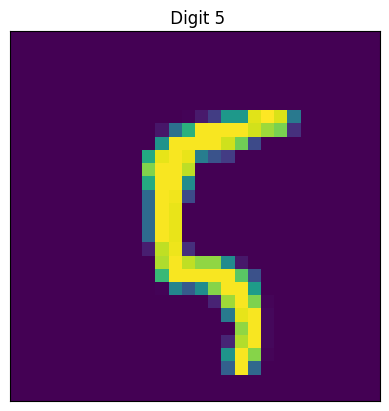

min and max value in image:  0 255


In [2]:
# TODO: Load the MNIST Data
def show_min_max(array, i):
  random_image = array[i]
  print("min and max value in image: ", random_image.min(), random_image.max())
def plot_image(array, i, labels):
  plt.imshow(np.squeeze(array[i]))
  plt.title(" Digit " + str(labels[i]))
  plt.xticks([])
  plt.yticks([])
  plt.show()
img_rows, img_cols = 28, 28
num_classes = 10
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
(train_images_backup, train_labels_backup), (test_images_backup, test_labels_backup) = mnist.load_data()
print(train_images.shape)
print(test_images.shape)
train_images = train_images.reshape(train_images.shape[0],  img_rows, img_cols, 1)
test_images = test_images.reshape(test_images.shape[0], img_rows, img_cols, 1)
input_shape = (img_rows, img_cols, 1)
plot_image(train_images, 100, train_labels)
show_min_max(train_images, 100)


Running The MNIST Model
---
Now that the model is defined, it can be run on the MNIST data.

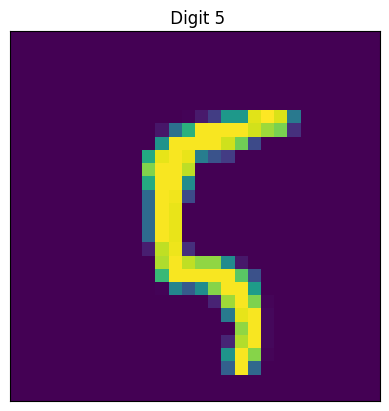

min and max value in image:  0.0 1.0


In [3]:
# TODO: Run the network on MNIST
train_images = train_images.astype('float32')
test_images = test_images.astype('float32')
train_images /= 255
test_images /= 255
plot_image(train_images, 100, train_labels)
show_min_max(train_images, 100)
train_labels = keras.utils.to_categorical(train_labels, num_classes)
test_labels = keras.utils.to_categorical(test_labels, num_classes)

Export The MNIST Model
---
Download The MNIST Model

In [ ]:
# TODO Export the MNIST Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
epochs = 10
model = Sequential()
model.add(Flatten(input_shape=input_shape))
model.add(Dense(16, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=epochs, shuffle=True)
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print('\nTest accuracy:', test_acc)


model.save('my_model.h5')

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 16)                12560     
                                                                 
 dense_1 (Dense)             (None, 10)                170       
                                                                 
Total params: 12,730
Trainable params: 12,730
Non-trainable params: 0
_________________________________________________________________
Epoch 1/10
1875/1875 [==============================] - 3s 1ms/step - loss: 0.4447 - accuracy: 0.8714
Epoch 2/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.2574 - accuracy: 0.9259
Epoch 3/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.2246 - accuracy: 0.9351
Epoch 4/10